In [35]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..',)))
from lib.utils.numpy import *

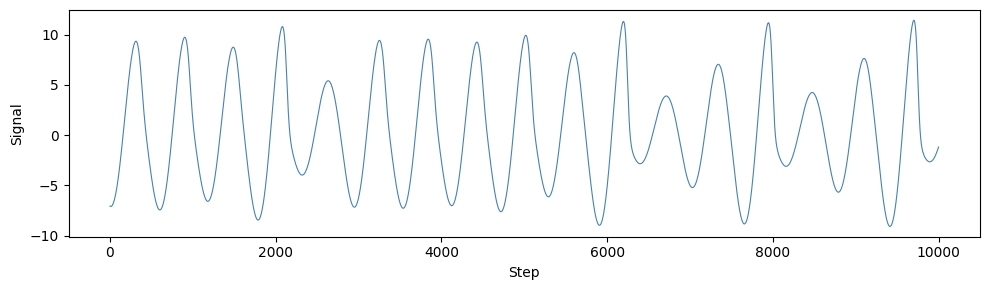

In [36]:
# LOAD DATA
# data should be a 1D numpy array
dataset = np.loadtxt('../data/chaotic_data/rossler_system.csv', delimiter=',')
dataset = dataset[: ,0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

Train interval : [0 : 2000]
Test interval  : [2000 : 2500]
Warmup length  : 200
Pred. length   : 300
MSE   : 61993159.3396907151
RMSE  : 7873.5734796654
NRMSE : 5153.1096633358


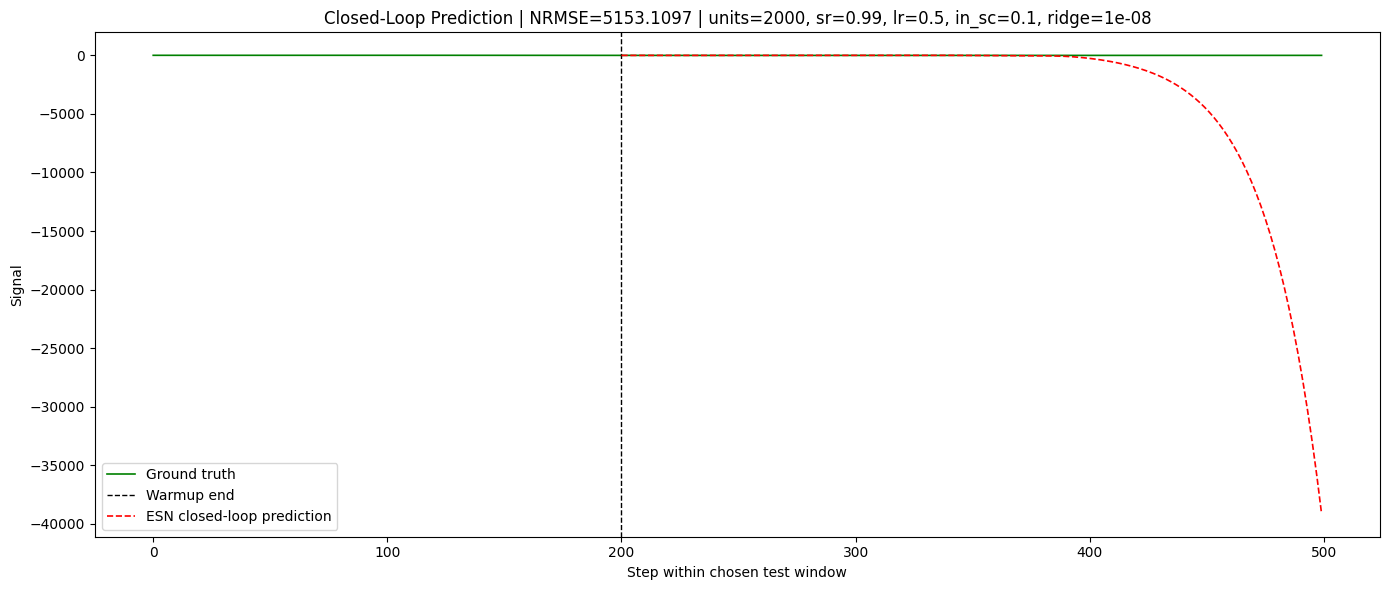

In [37]:
# USER PARAMETERS
train_len = 2000   # training uses data[0:train_len]
test_start = 2000  # start index of test window in the full dataset
test_len = 500    # total length of chosen test window
warmup_len = 200   # first part of test window used for synchronization
ridge_coef = 1e-8

res_units = 2000
leak_rate = 0.5
spectral_radius = 0.99
input_scaling = 0.1
bias_scaling = 1.0
connectivity = 1.0
seed = 42

train_washout = 100

# DATA PREPARATION
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

# Training split
X_train = X[:train_len]
Y_train = Y[:train_len]

# Test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# ESN DEFINITION
Win, W, Wbias = generate_esn(
    n_inputs=X.shape[1],
    n_reservoir=res_units,
    spectral_radius=spectral_radius,
    input_scaling=input_scaling,
    bias_scaling=bias_scaling,
    connectivity=connectivity,
    seed=seed,)

# TRAINING
Wout = fit_esn(
    X_train=X_train,
    Y_train=Y_train,
    Win=Win,
    W=W,
    Wbias=Wbias,
    leak_rate=leak_rate,
    washout=train_washout,
    ridge=ridge_coef,
)

# TESTING ON AN ARBITRARY WINDOW
# reset ESN state
x_test = np.zeros((res_units, 1))

# warm up with the first warmup_len true samples of the test window
if warmup_len > 0:
    _, _, x_test = run_esn_open_loop(
        X_seq=X_test[:warmup_len],
        Win=Win,
        W=W,
        Wbias=Wbias,
        Wout=Wout,
        leak_rate=leak_rate,
        x0=x_test
    )

# start closed-loop prediction from the next point
pred_len = test_len - warmup_len

current_input = X_test[warmup_len]   # first seed after warmup

Y_pred, _ = predict_closed_loop(
    initial_input=current_input,
    steps=pred_len,
    Win=Win,
    W=W,
    Wbias=Wbias,
    Wout=Wout,
    leak_rate=leak_rate,
    x0=x_test
)

# Ground truth aligned with prediction interval
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]
Y_pred = Y_pred[:, 0]


# ERROR METRICS
mse = np.mean((Y_true - Y_pred) ** 2)
rmse = np.sqrt(mse)
nrmse_val = rmse / (np.std(Y_true) + 1e-12)

print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse_val:.10f}")


# VISUALIZATION
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k', linewidth=1.0, label="Warmup end")
ax.plot(np.arange(warmup_len, warmup_len + pred_len), Y_pred, linestyle="--", c='red', linewidth=1.2, label="ESN closed-loop prediction")
ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse_val:.4f} | "
    f"units={res_units}, sr={spectral_radius}, "
    f"lr={leak_rate}, in_sc={input_scaling}, "
    f"ridge={ridge_coef:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()